In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv(r"/content/student_placement_synthetic.csv")

In [ ]:
df

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,IT,Tier-3,6.08,0,3.1,5.4,67.4,4.3,9.1,3.8,2,3,2,0,0,3,0,NaN
99996,IT,Tier-3,7.46,0,4.8,6.8,59.5,7.6,5.6,2.4,1,2,3,0,1,0,1,16.58
99997,EE,Tier-2,7.94,0,4.9,9.1,55.1,6.1,3.5,5.2,0,2,1,0,1,2,1,17.24
99998,ME,Tier-3,6.63,0,5.0,8.0,65.0,5.7,6.2,0.2,1,4,2,0,0,1,1,17.01


In [ ]:
df.columns

Index(['branch', 'college_tier', 'cgpa', 'backlogs', 'coding_skills',
       'dsa_score', 'aptitude_score', 'communication_skills', 'ml_knowledge',
       'system_design', 'internships', 'projects_count', 'certifications',
       'hackathons', 'open_source_contributions', 'extracurriculars',
       'placement_status', 'salary_package_lpa'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   branch                     100000 non-null  object 
 1   college_tier               100000 non-null  object 
 2   cgpa                       100000 non-null  float64
 3   backlogs                   100000 non-null  int64  
 4   coding_skills              100000 non-null  float64
 5   dsa_score                  100000 non-null  float64
 6   aptitude_score             100000 non-null  float64
 7   communication_skills       100000 non-null  float64
 8   ml_knowledge               100000 non-null  float64
 9   system_design              100000 non-null  float64
 10  internships                100000 non-null  int64  
 11  projects_count             100000 non-null  int64  
 12  certifications             100000 non-null  int64  
 13  hackathons                 100

In [ ]:
''' every column didnt have null values but only
salary_package_lpa have large amt of null values  '''

'''
Goal:
1. Placement Prediction – Binary classification (placed vs not placed)
2. Salary Prediction – Regression on salary_package_lpa
3. Feature Importance Analysis – Which factors matter most for placement?
4. Fairness Auditing – Bias analysis by branch, college tier, or skill set
5. EDA Practice – Great for beginners exploring distributions and correlations
'''

'\nGoal:\n1. Placement Prediction – Binary classification (placed vs not placed)\n2. Salary Prediction – Regression on salary_package_lpa\n3. Feature Importance Analysis – Which factors matter most for placement?\n4. Fairness Auditing – Bias analysis by branch, college tier, or skill set\n5. EDA Practice – Great for beginners exploring distributions and correlations\n'

In [ ]:
df.head()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42


In [ ]:
df.tail()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
99995,IT,Tier-3,6.08,0,3.1,5.4,67.4,4.3,9.1,3.8,2,3,2,0,0,3,0,NaN
99996,IT,Tier-3,7.46,0,4.8,6.8,59.5,7.6,5.6,2.4,1,2,3,0,1,0,1,16.58
99997,EE,Tier-2,7.94,0,4.9,9.1,55.1,6.1,3.5,5.2,0,2,1,0,1,2,1,17.24
99998,ME,Tier-3,6.63,0,5.0,8.0,65.0,5.7,6.2,0.2,1,4,2,0,0,1,1,17.01
99999,ECE,Tier-1,7.00,0,2.8,5.3,64.5,5.7,5.7,3.4,0,2,2,2,0,1,1,14.98


In [ ]:
df.isnull().sum()

,0
branch,0
college_tier,0
cgpa,0
backlogs,0
coding_skills,0
dsa_score,0
aptitude_score,0
communication_skills,0
ml_knowledge,0
system_design,0


In [ ]:
# Finds how much duplicates rows in dataset
df[df.duplicated()]
# conclusion :- no row are duplicated

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa


In [ ]:
df.drop_duplicates()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,IT,Tier-3,6.08,0,3.1,5.4,67.4,4.3,9.1,3.8,2,3,2,0,0,3,0,NaN
99996,IT,Tier-3,7.46,0,4.8,6.8,59.5,7.6,5.6,2.4,1,2,3,0,1,0,1,16.58
99997,EE,Tier-2,7.94,0,4.9,9.1,55.1,6.1,3.5,5.2,0,2,1,0,1,2,1,17.24
99998,ME,Tier-3,6.63,0,5.0,8.0,65.0,5.7,6.2,0.2,1,4,2,0,0,1,1,17.01


In [ ]:
# placements vs intenships
# CGPA, backlogs, coding_skills, dsa_score, aptitude_score, communication_skills VS placements
# branch VS placements
# College Tier VS placements
# ml_knowledge	system_design VS  placements
# Certifications	hackathons	open_source_contributions	extracurriculars	vs placements

In [ ]:
# College Tier VS placements

In [ ]:
# Total counts of college Tier
df['college_tier'].value_counts(normalize='index')*100

,proportion
college_tier,
Tier-3,45.222
Tier-2,39.910
Tier-1,14.868


In [ ]:
pd.crosstab(df['college_tier'], df['placement_status'],normalize='index')*100

placement_status,0,1
college_tier,,
Tier-1,16.942427,83.057573
Tier-2,27.439238,72.560762
Tier-3,39.925258,60.074742


In [ ]:
'''
College tier has some effect on placement, but not very strong.
Tier 1 and Tier 2 students have higher placement rates,
while Tier 3 students have lower placement rates proportionally.
'''

'\nCollege tier has some effect on placement, but not very strong.\nTier 1 and Tier 2 students have higher placement rates,\nwhile Tier 3 students have lower placement rates proportionally.\n'

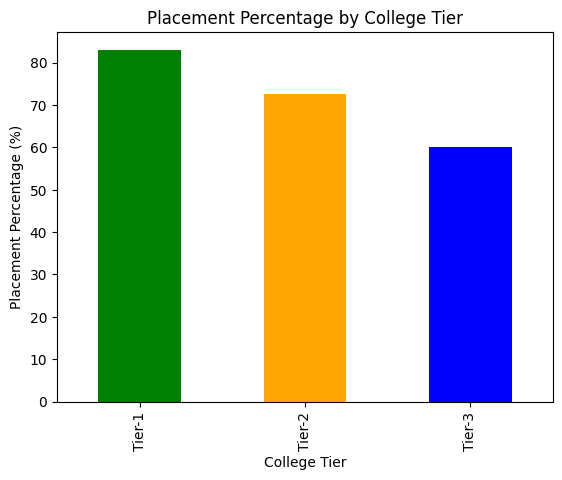

In [ ]:
import matplotlib.pyplot as plt

bar_graph = pd.crosstab(df['college_tier'], df['placement_status'], normalize='index')[1] * 100

bar_graph.plot(kind='bar', color=['green','Orange','blue'])
plt.title("Placement Percentage by College Tier")
plt.xlabel("College Tier")
plt.ylabel("Placement Percentage (%)")
plt.show()

In [ ]:
'''
Tier 2 colleges have the most placed students, Tier 3 also does well,
and Tier 1 has the least. This shows that a higher college tier
does not always mean better placement.
'''

'\nTier 2 colleges have the most placed students, Tier 3 also does well,\nand Tier 1 has the least. This shows that a higher college tier\ndoes not always mean better placement.\n'

In [ ]:
# internships vs placement

In [ ]:
pd.crosstab(df['internships'],df['placement_status'],normalize='index')*100

placement_status,0,1
internships,,
0,37.235529,62.764471
1,31.715564,68.284436
2,26.816261,73.183739
3,22.815928,77.184072


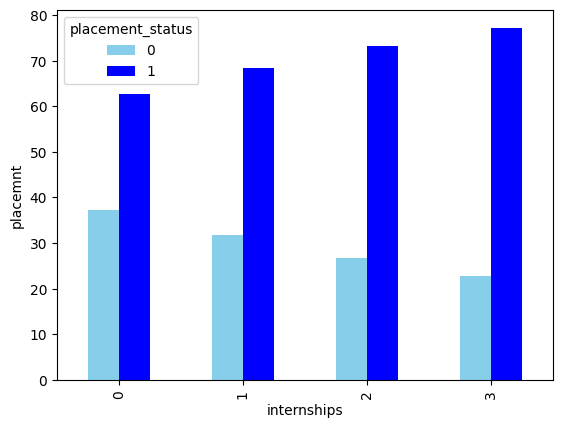

In [ ]:
internship=pd.crosstab(df['internships'],df['placement_status'],normalize='index')*100
internship.plot(kind='bar', color=['skyblue','blue'])
plt.xlabel("internships")
plt.ylabel("placemnt")
plt.show()

In [ ]:
'''
Observation:
1. As the number of internships increases, the placement percentage also increases.
2. Students with 3 internships have the highest placement rate (77%),
while students with 0 internships have the lowest (63%).
'''

'\nObservation:\n1. As the number of internships increases, the placement percentage also increases.\n2. Students with 3 internships have the highest placement rate (77%),\nwhile students with 0 internships have the lowest (63%).\n'

In [ ]:
branch_placement = pd.crosstab(df['branch'], df['placement_status'], normalize='index') * 100
branch_placement

placement_status,0,1
branch,,
CE,35.335196,64.664804
CSE,28.651282,71.348718
Chemical,35.446774,64.553226
ECE,30.423723,69.576277
EE,33.650347,66.349653
IT,29.106754,70.893246
ME,33.594270,66.405730


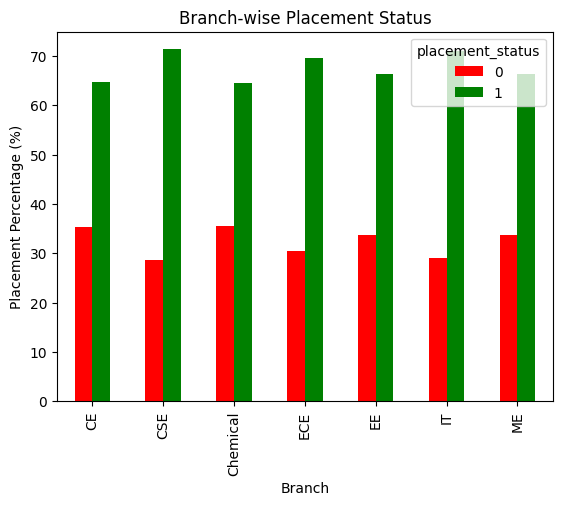

In [ ]:
branch_placement.plot(kind='bar', color=['red','green'])
plt.title("Branch-wise Placement Status")
plt.xlabel("Branch")
plt.ylabel("Placement Percentage (%)")
plt.show()

In [ ]:
'''
Branch affects placement to some extent — CSE and IT students have the highest placement rates,
while CE and Chemical have slightly lower placement rates.
'''

'\nBranch affects placement to some extent — CSE and IT students have the highest placement rates,\nwhile CE and Chemical have slightly lower placement rates.\n'

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

skills = ['cgpa', 'backlogs', 'coding_skills', 'dsa_score', 'aptitude_score',
          'communication_skills', 'ml_knowledge', 'system_design']

scaler = MinMaxScaler()
skills_scaled = scaler.fit_transform(df[skills])

# Invert backlogs (because more backlogs = bad)
skills_scaled[:, skills.index('backlogs')] = 1 - skills_scaled[:, skills.index('backlogs')]

# Create overall skill score
df['overall_skill_score'] = np.mean(skills_scaled, axis=1)


In [ ]:
extras = ['projects_count', 'certifications', 'hackathons',
          'open_source_contributions', 'extracurriculars']

extras_scaled = scaler.fit_transform(df[extras])

df['overall_extra_score'] = np.mean(extras_scaled, axis=1)

In [ ]:
df

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa,overall_skill_score,overall_extra_score
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75,0.487483,0.826667
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN,0.602500,0.160000
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06,0.637135,0.486667
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN,0.461597,0.310000
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42,0.438194,0.346667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,IT,Tier-3,6.08,0,3.1,5.4,67.4,4.3,9.1,3.8,2,3,2,0,0,3,0,NaN,0.539757,0.420000
99996,IT,Tier-3,7.46,0,4.8,6.8,59.5,7.6,5.6,2.4,1,2,3,0,1,0,1,16.58,0.583802,0.330000
99997,EE,Tier-2,7.94,0,4.9,9.1,55.1,6.1,3.5,5.2,0,2,1,0,1,2,1,17.24,0.608177,0.363333
99998,ME,Tier-3,6.63,0,5.0,8.0,65.0,5.7,6.2,0.2,1,4,2,0,0,1,1,17.01,0.548160,0.326667


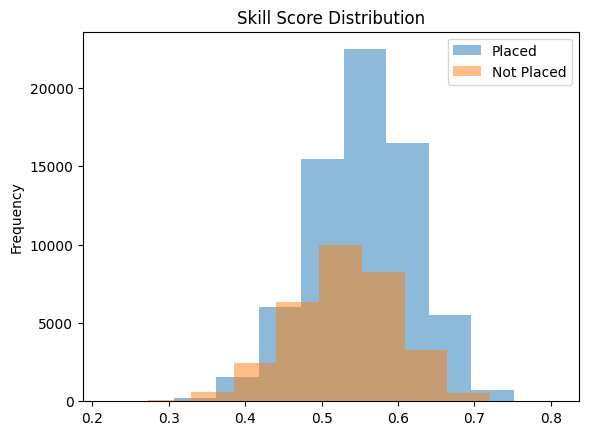

In [ ]:
df[df['placement_status']==1]['overall_skill_score'].plot(kind='hist', alpha=0.5, label='Placed')
df[df['placement_status']==0]['overall_skill_score'].plot(kind='hist', alpha=0.5, label='Not Placed')
plt.legend()
plt.title("Skill Score Distribution")
plt.show()

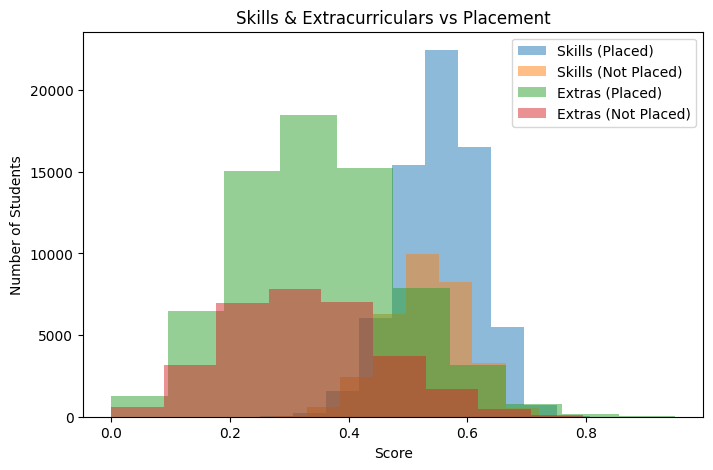

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Skills
plt.hist(df[df['placement_status']==1]['overall_skill_score'],
         alpha=0.5, label='Skills (Placed)')

plt.hist(df[df['placement_status']==0]['overall_skill_score'],
         alpha=0.5, label='Skills (Not Placed)')

# Extracurriculars
plt.hist(df[df['placement_status']==1]['overall_extra_score'],
         alpha=0.5, label='Extras (Placed)')

plt.hist(df[df['placement_status']==0]['overall_extra_score'],
         alpha=0.5, label='Extras (Not Placed)')

plt.title("Skills & Extracurriculars vs Placement")
plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.legend()
plt.show()

In [ ]:
print("The minimum  overall_skill_score:",df['overall_skill_score'].min())
print("The maximum overall_skill_score",df['overall_skill_score'].max())
print("The minimum overall_extra_score",df['overall_extra_score'].min())
print("The maximum overall_extra_score",df['overall_extra_score'].max())

The minimum  overall_skill_score: 0.21750000000000003
The maximum overall_skill_score 0.8075868055555557
The minimum overall_extra_score 0.0
The maximum overall_extra_score 0.95


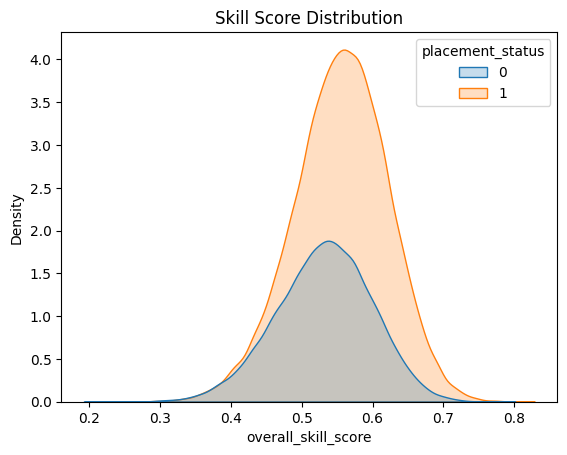

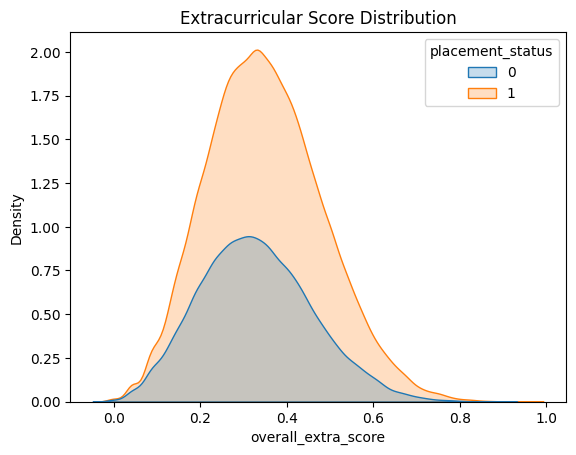

In [ ]:
import seaborn as sns

sns.kdeplot(data=df, x='overall_skill_score', hue='placement_status', fill=True)
plt.title("Skill Score Distribution")
plt.show()

sns.kdeplot(data=df, x='overall_extra_score', hue='placement_status', fill=True)
plt.title("Extracurricular Score Distribution")
plt.show()

In [ ]:
df[['overall_skill_score','overall_extra_score','placement_status']]

,overall_skill_score,overall_extra_score,placement_status
0,0.487483,0.826667,1
1,0.602500,0.160000,0
2,0.637135,0.486667,1
3,0.461597,0.310000,0
4,0.438194,0.346667,1
...,...,...,...
99995,0.539757,0.420000,0
99996,0.583802,0.330000,1
99997,0.608177,0.363333,1
99998,0.548160,0.326667,1


In [ ]:
df['skill_level'] = pd.qcut(df['overall_skill_score'], q=3, labels=['Low','Medium','High'])
df['extra_level'] = pd.qcut(df['overall_extra_score'], q=3, labels=['Low','Medium','High'])

result = pd.crosstab([df['skill_level'], df['extra_level']],
                     df['placement_status'],
                     normalize='index') * 100
print(result)


placement_status                 0          1
skill_level extra_level                      
Low         Low          43.263757  56.736243
            Medium       40.522074  59.477926
            High         35.713628  64.286372
Medium      Low          35.661962  64.338038
            Medium       31.106115  68.893885
            High         27.150635  72.849365
High        Low          26.416431  73.583569
            Medium       22.896986  77.103014
            High         20.725341  79.274659


In [ ]:
final_df = df[['skill_level', 'extra_level', 'placement_status']]
final_df

,skill_level,extra_level,placement_status
0,Low,High,1
1,High,Low,0
2,High,High,1
3,Low,Medium,0
4,Low,Medium,1
...,...,...,...
99995,Medium,High,0
99996,High,Medium,1
99997,High,Medium,1
99998,Medium,Medium,1


In [ ]:
df

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,...,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa,overall_skill_score,overall_extra_score,skill_level,extra_level
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,...,4,3,2,1,1,14.75,0.487483,0.826667,Low,High
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,...,0,0,0,0,0,NaN,0.602500,0.160000,High,Low
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,...,2,1,2,0,1,19.06,0.637135,0.486667,High,High
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,...,3,0,0,0,0,NaN,0.461597,0.310000,Low,Medium
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,...,0,3,0,1,1,13.42,0.438194,0.346667,Low,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,IT,Tier-3,6.08,0,3.1,5.4,67.4,4.3,9.1,3.8,...,2,0,0,3,0,NaN,0.539757,0.420000,Medium,High
99996,IT,Tier-3,7.46,0,4.8,6.8,59.5,7.6,5.6,2.4,...,3,0,1,0,1,16.58,0.583802,0.330000,High,Medium
99997,EE,Tier-2,7.94,0,4.9,9.1,55.1,6.1,3.5,5.2,...,1,0,1,2,1,17.24,0.608177,0.363333,High,Medium
99998,ME,Tier-3,6.63,0,5.0,8.0,65.0,5.7,6.2,0.2,...,2,0,0,1,1,17.01,0.548160,0.326667,Medium,Medium


In [ ]:
result = pd.crosstab(
    [df['skill_level'], df['extra_level']],
    df['placement_status']
)

print(result)

placement_status            0     1
skill_level extra_level            
Low         Low          4788  6279
            Medium       4626  6790
            High         3876  6977
Medium      Low          3992  7202
            Medium       3459  7661
            High         2992  8028
High        Low          2984  8312
            Medium       2545  8570
            High         2263  8656


In [ ]:
pd.crosstab([df['skill_level'], df['extra_level']], df['placement_status'], normalize='index') * 100

placement_status                 0          1
skill_level extra_level                      
Low         Low          43.263757  56.736243
            Medium       40.522074  59.477926
            High         35.713628  64.286372
Medium      Low          35.661962  64.338038
            Medium       31.106115  68.893885
            High         27.150635  72.849365
High        Low          26.416431  73.583569
            Medium       22.896986  77.103014
            High         20.725341  79.274659

In [ ]:
pd.crosstab([df['skill_level'], df['extra_level']], df['placement_status'], normalize=True) * 100

placement_status             0      1
skill_level extra_level              
Low         Low          4.788  6.279
            Medium       4.626  6.790
            High         3.876  6.977
Medium      Low          3.992  7.202
            Medium       3.459  7.661
            High         2.992  8.028
High        Low          2.984  8.312
            Medium       2.545  8.570
            High         2.263  8.656

In [ ]:
'''
High skills increase placement chances,
 but do not guarantee placement,
 as other factors also influence the outcome.
'''

'\nHigh skills increase placement chances,\n but do not guarantee placement,\n as other factors also influence the outcome.\n'

In [ ]:
high_high_not_placed = df[
    (df['skill_level'] == 'High') &
    (df['extra_level'] == 'High') &
    (df['placement_status'] == 0)
]

high_high_not_placed

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,...,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa,overall_skill_score,overall_extra_score,skill_level,extra_level
102,ECE,Tier-3,7.15,0,6.9,3.3,56.8,3.9,10.0,6.7,...,4,0,0,3,0,NaN,0.611042,0.440000,High,High
236,ECE,Tier-3,7.40,0,7.1,6.0,70.3,9.1,3.7,3.2,...,2,0,1,1,0,NaN,0.627344,0.466667,High,High
360,ECE,Tier-3,8.31,0,6.1,4.9,84.3,6.1,2.7,3.0,...,3,1,1,1,0,NaN,0.582344,0.503333,High,High
365,ECE,Tier-2,6.18,0,6.2,4.6,85.1,7.4,6.8,5.8,...,4,2,0,2,0,NaN,0.640747,0.506667,High,High
445,Chemical,Tier-2,8.02,1,5.9,7.5,73.7,6.2,2.4,5.8,...,2,3,0,1,0,NaN,0.584045,0.406667,High,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99837,CSE,Tier-2,8.31,1,9.0,4.9,52.1,6.8,4.4,5.6,...,1,1,0,2,0,NaN,0.594115,0.410000,High,High
99846,CSE,Tier-3,6.55,1,3.7,8.1,53.7,10.0,8.6,7.9,...,2,0,0,3,0,NaN,0.656476,0.460000,High,High
99847,IT,Tier-2,7.53,0,4.7,7.0,77.8,5.0,6.9,2.4,...,2,3,0,1,0,NaN,0.595382,0.446667,High,High
99953,IT,Tier-3,6.93,0,3.2,7.1,75.6,8.3,4.2,4.0,...,1,1,0,3,0,NaN,0.592083,0.436667,High,High


In [ ]:
high_high_placed = df[
    (df['skill_level'] == 'High') &
    (df['extra_level'] == 'High') &
    (df['placement_status'] == 1)
]
high_high_placed

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,...,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa,overall_skill_score,overall_extra_score,skill_level,extra_level
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,...,2,1,2,0,1,19.06,0.637135,0.486667,High,High
26,CSE,Tier-1,8.83,0,7.2,8.3,76.7,7.2,7.8,0.2,...,0,3,0,3,1,22.55,0.687830,0.480000,High,High
29,CSE,Tier-2,9.06,0,6.3,5.7,58.7,6.8,6.4,6.0,...,1,2,2,0,1,20.47,0.665330,0.423333,High,High
37,CSE,Tier-3,7.95,0,4.6,7.2,74.4,6.1,3.9,6.6,...,1,1,1,1,1,17.96,0.630486,0.403333,High,High
58,CSE,Tier-1,6.83,1,7.2,7.7,72.7,6.6,6.7,5.6,...,0,0,2,2,1,18.48,0.635330,0.413333,High,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99920,CSE,Tier-3,6.69,0,5.5,7.8,50.3,7.6,6.5,6.2,...,0,0,2,1,1,20.33,0.635747,0.426667,High,High
99949,Chemical,Tier-2,8.07,0,6.9,6.2,62.2,6.6,4.6,3.9,...,4,2,0,3,1,19.08,0.613924,0.573333,High,High
99975,IT,Tier-2,8.97,0,7.8,6.4,74.9,2.8,5.8,3.8,...,1,1,2,0,1,18.04,0.628767,0.436667,High,High
99978,ECE,Tier-3,7.66,0,5.2,4.8,72.4,4.4,6.9,5.7,...,1,3,1,2,1,16.10,0.598958,0.643333,High,High


In [ ]:
# Calculate means
not_placed_mean = high_high_not_placed.mean(numeric_only=True)
placed_mean = high_high_placed.mean(numeric_only=True)

# Combine into one DataFrame
comparison = pd.concat([not_placed_mean, placed_mean], axis=1)

# Rename columns
comparison.columns = ['Not Placed', 'Placed']

print(comparison)

                           Not Placed     Placed
cgpa                         7.304410   7.555969
backlogs                     0.155988   0.155268
coding_skills                6.351613   6.559277
dsa_score                    6.151834   6.288447
aptitude_score              68.364118  68.852576
communication_skills         6.483606   6.510074
ml_knowledge                 5.482280   5.315573
system_design                4.853867   4.650739
internships                  0.919576   1.136784
projects_count               2.758285   2.922828
certifications               1.923111   2.028535
hackathons                   1.149801   1.202750
open_source_contributions    0.868758   0.848544
extracurriculars             1.734865   1.669709
placement_status             0.000000   1.000000
salary_package_lpa                NaN  18.679140
overall_skill_score          0.614156   0.620716
overall_extra_score          0.485674   0.494692


In [ ]:
b1 = high_high_not_placed['branch'].value_counts(normalize=True) * 100
b2 = high_high_placed['branch'].value_counts(normalize=True) * 100

branch_compare = pd.concat([b1, b2], axis=1)
branch_compare.columns = ['Not Placed', 'Placed']

print(branch_compare)

          Not Placed     Placed
branch                         
CSE        22.138754  26.305453
ECE        14.361467  14.822089
IT         14.007954  16.762939
EE         13.168361  11.598891
ME         12.991604  11.679760
Chemical   11.931065   9.623383
CE         11.400795   9.207486


In [ ]:
t1 = high_high_not_placed['college_tier'].value_counts(normalize=True) * 100
t2 = high_high_placed['college_tier'].value_counts(normalize=True) * 100

tier_compare = pd.concat([t1, t2], axis=1)
tier_compare.columns = ['Not Placed', 'Placed']

print(tier_compare)

              Not Placed     Placed
college_tier                       
Tier-3         56.871410  38.285582
Tier-2         34.776845  42.363678
Tier-1          8.351745  19.350739


In [ ]:
'''
Placement outcomes are influenced by multiple factors, including skills, internships, certifications, branch, and college tier.
While higher skill levels increase placement chances,
students from certain branches and lower-tier colleges may still face challenges in securing placements
'''

'\nPlacement outcomes are influenced by multiple factors, including skills, internships, certifications, branch, and college tier.\nWhile higher skill levels increase placement chances,\nstudents from certain branches and lower-tier colleges may still face challenges in securing placements\n'

In [ ]:
# which factors affect to packages

In [ ]:
df.groupby('skill_level')['salary_package_lpa'].mean()

/tmp/ipykernel_486/1736610251.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('skill_level')['salary_package_lpa'].mean()


,salary_package_lpa
skill_level,
Low,15.845646
Medium,17.045677
High,18.691043


In [ ]:
df.groupby('extra_level')['salary_package_lpa'].mean()

/tmp/ipykernel_486/3484750432.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('extra_level')['salary_package_lpa'].mean()


,salary_package_lpa
extra_level,
Low,17.341148
Medium,17.301848
High,17.283495


In [ ]:
''' the extra curricular activities like 'projects_count', 'certifications', 'hackathons',
          'open_source_contributions', 'extracurriculars'
          not much affect the pacakges
    high skills affect the packages
    according to skill packages values are defined
  '''

" the extra curricular activities like 'projects_count', 'certifications', 'hackathons',\n          'open_source_contributions', 'extracurriculars'\n          not much affect the pacakges\n    high skills affect the packages\n    according to skill packages values are defined\n  "

In [ ]:
# work on valid salary data
df_salary = df[df['salary_package_lpa'].notna()]

In [ ]:
# tier vs salary
df_salary.groupby('college_tier')['salary_package_lpa'].mean()

,salary_package_lpa
college_tier,
Tier-1,19.341536
Tier-2,17.169251
Tier-3,16.531575


In [ ]:
# branch vs salary
df_salary.groupby('branch')['salary_package_lpa'].mean()

,salary_package_lpa
branch,
CE,17.348112
CSE,17.326434
Chemical,17.311982
ECE,17.291240
EE,17.303424
IT,17.277354
ME,17.301258


In [ ]:
df_salary.groupby('internships')['salary_package_lpa'].mean()

,salary_package_lpa
internships,
0,15.964756
1,17.112709
2,18.275366
3,19.497538


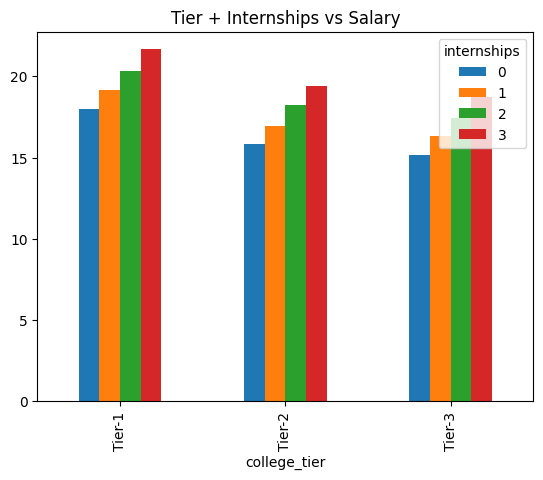

In [ ]:
pd.crosstab(
    df_salary['college_tier'],
    df_salary['internships'],
    values=df_salary['salary_package_lpa'],
    aggfunc='mean'
).plot(kind='bar')
plt.title("Tier + Internships vs Salary")
plt.show()

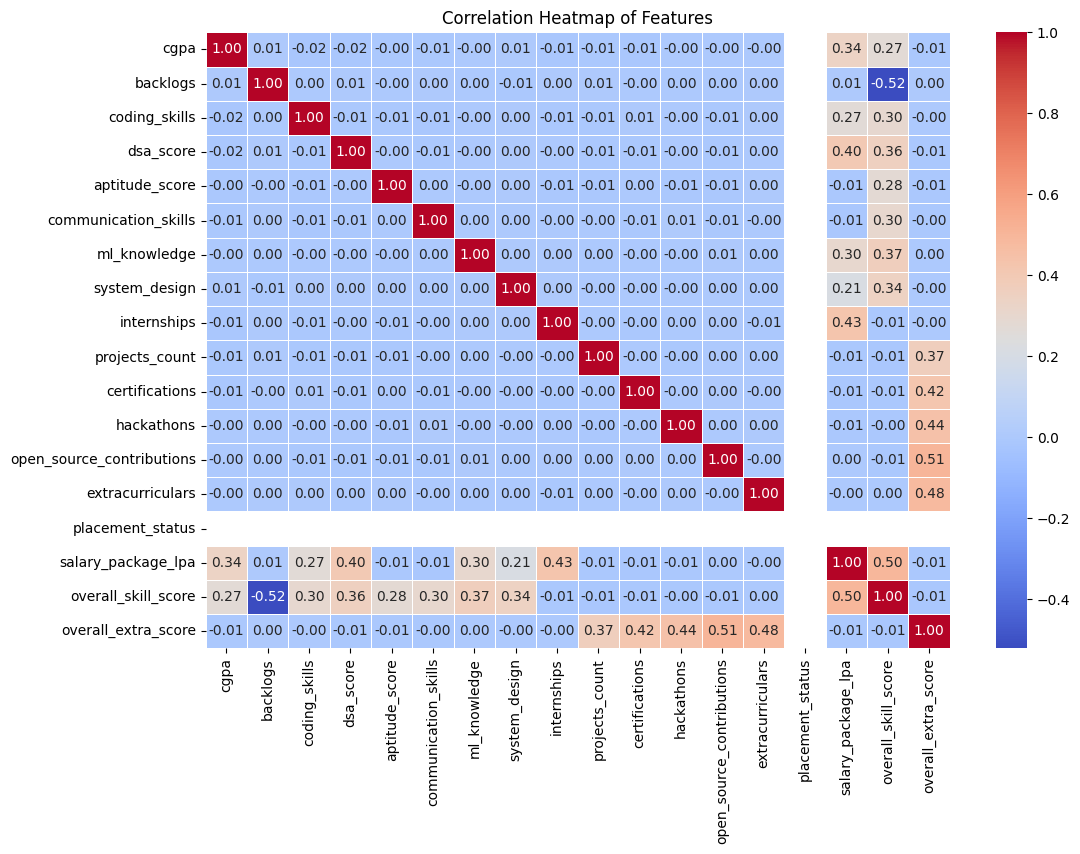

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_df = df_salary.select_dtypes(include=['number'])

# Correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap of Features")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = df[['cgpa','coding_skills','dsa_score','aptitude_score','communication_skills']]
y = df['placement_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.67605


In [ ]:
df['placement_label'] = df['placement_status'].apply(
    lambda x: 'Placed' if x == 1 else 'Not Placed'
)

In [ ]:
df['placement_label'] = df['placement_status'].apply(
    lambda x: 'Placed' if x == 1 else 'Not Placed'
)

In [ ]:
df

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,...,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa,overall_skill_score,overall_extra_score,skill_level,extra_level,placement_label
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,...,3,2,1,1,14.75,0.487483,0.826667,Low,High,Placed
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,...,0,0,0,0,NaN,0.602500,0.160000,High,Low,Not Placed
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,...,1,2,0,1,19.06,0.637135,0.486667,High,High,Placed
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,...,0,0,0,0,NaN,0.461597,0.310000,Low,Medium,Not Placed
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,...,3,0,1,1,13.42,0.438194,0.346667,Low,Medium,Placed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,IT,Tier-3,6.08,0,3.1,5.4,67.4,4.3,9.1,3.8,...,0,0,3,0,NaN,0.539757,0.420000,Medium,High,Not Placed
99996,IT,Tier-3,7.46,0,4.8,6.8,59.5,7.6,5.6,2.4,...,0,1,0,1,16.58,0.583802,0.330000,High,Medium,Placed
99997,EE,Tier-2,7.94,0,4.9,9.1,55.1,6.1,3.5,5.2,...,0,1,2,1,17.24,0.608177,0.363333,High,Medium,Placed
99998,ME,Tier-3,6.63,0,5.0,8.0,65.0,5.7,6.2,0.2,...,0,0,1,1,17.01,0.548160,0.326667,Medium,Medium,Placed
